# 01 Linear 训练（Stage1 + Stage2）

对齐 `code/run_infer_llm2_pdf.py` 的线性分支：
- 自训练 BPE tokenizer
- TF-IDF ngram(3,5), min_df=2
- Voting(MNB + SGD)
- Stage1/Stage2 伪标签增强


In [1]:
from pathlib import Path

import gc
import numpy as np
import pandas as pd
from datasets import Dataset
from scipy.sparse import vstack
from scipy.stats import rankdata
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_recall_fscore_support,
    log_loss,
)
from sklearn.naive_bayes import MultinomialNB
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from tokenizers.normalizers import NFD
from transformers import PreTrainedTokenizerFast


/Users/songling/Documents/conda/miniconda3/envs/llm-detect/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

TRAIN_STAGE1 = ROOT / 'code/train1.csv'
TRAIN_STAGE2 = ROOT / 'data/train_v2_drcat_02.csv'
VALID_PATH = ROOT / 'code/nonTargetText_llm_slightly_modified_gen.csv'
TEST_PATH = ROOT / 'data/llm-detect-ai-generated-text/test_essays.csv'

OUT_DIR = ROOT / 'outputs/notebook_linear'
OUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE1_VOCAB_SIZE = 5000
STAGE2_VOCAB_SIZE = 3500

STAGE2_DROP_SOURCES = [
    'mistral7binstruct_v2',
    'mistral7binstruct_v1',
    'falcon_180b_v1',
    'llama2_chat',
    'llama_70b_v1',
    'NousResearch/Llama-2-7b-chat-hf',
]

print('ROOT =', ROOT)
print('OUT_DIR =', OUT_DIR)

ROOT = /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text
OUT_DIR = /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/notebook_linear


In [3]:
def clean_text(s: pd.Series) -> pd.Series:
    return s.fillna('').astype(str).str.strip().str.replace('\n', '', regex=False)


def ensure_text_label(df: pd.DataFrame, text_col: str = 'text', label_col: str = 'label') -> pd.DataFrame:
    if text_col not in df.columns:
        raise ValueError(f'missing text column: {text_col}')

    out = df.copy()
    out[text_col] = clean_text(out[text_col])

    if label_col not in out.columns:
        if 'generated' in out.columns:
            out[label_col] = out['generated'].astype(int)
        elif 'source' in out.columns:
            out[label_col] = (out['source'] != 'persuade_corpus').astype(int)
        else:
            raise ValueError('missing label column and cannot infer from generated/source')

    return out[[text_col, label_col]].rename(columns={text_col: 'text', label_col: 'label'})


def to_label_array(n_false: int, n_true: int) -> np.ndarray:
    return np.concatenate([np.zeros(n_false, dtype=int), np.ones(n_true, dtype=int)])


def train_bpe_tokenizer(corpus_df: pd.DataFrame, vocab_size: int) -> PreTrainedTokenizerFast:
    raw_tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
    raw_tokenizer.normalizer = normalizers.Sequence([NFD()])
    raw_tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel()

    special_tokens = ['[UNK]', '[PAD]', '[CLS]', '[SEP]', '[MASK]']
    trainer = trainers.BpeTrainer(vocab_size=vocab_size, special_tokens=special_tokens)

    ds = Dataset.from_pandas(corpus_df[['text']])

    def iter_text():
        for i in range(0, len(ds), 1000):
            yield ds[i:i+1000]['text']

    raw_tokenizer.train_from_iterator(iter_text(), trainer=trainer)
    return PreTrainedTokenizerFast(
        tokenizer_object=raw_tokenizer,
        unk_token='[UNK]',
        pad_token='[PAD]',
        cls_token='[CLS]',
        sep_token='[SEP]',
        mask_token='[MASK]',
    )


def augment_tokens(token_lists: list[list[str]]) -> list[list[str]]:
    return [x + x[::2] + x[1::2] for x in token_lists]


def dummy(x):
    return x


def build_features(train_tokens, fit_tokens, test_tokens):
    fit_vec = TfidfVectorizer(
        ngram_range=(3, 5),
        lowercase=False,
        sublinear_tf=True,
        analyzer='word',
        tokenizer=dummy,
        preprocessor=dummy,
        min_df=2,
        token_pattern=None,
        strip_accents='unicode',
    )
    fit_vec.fit(fit_tokens)

    vec = TfidfVectorizer(
        ngram_range=(3, 5),
        lowercase=False,
        sublinear_tf=True,
        vocabulary=fit_vec.vocabulary_,
        analyzer='word',
        tokenizer=dummy,
        preprocessor=dummy,
        min_df=2,
        token_pattern=None,
        strip_accents='unicode',
    )
    tf_train = vec.fit_transform(train_tokens)
    tf_test = vec.transform(test_tokens)
    return vec, tf_train, tf_test


def fit_linear(tf_train, y_train, alpha: float, max_iter: int, weights: list[float]):
    bayes = MultinomialNB(alpha=alpha)
    sgd = SGDClassifier(max_iter=max_iter, tol=1e-4, loss='modified_huber')
    clf = VotingClassifier(
        estimators=[('mnb', bayes), ('sgd', sgd)],
        weights=weights,
        voting='soft',
        n_jobs=1,
    )
    clf.fit(tf_train, y_train)
    return clf

def evaluate_binary_metrics(y_true, y_score, model_name: str, threshold: float = 0.5) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    return {
        'model': model_name,
        'auc_roc': roc_auc_score(y_true, y_score),
        'log_loss': log_loss(y_true, np.clip(y_score, 1e-6, 1 - 1e-6)),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def train_sgd_history(
    tf_train,
    y_train: np.ndarray,
    tf_valid,
    y_valid: np.ndarray,
    alpha: float = 1e-4,
    epochs: int = 12,
    random_state: int = 42,
):
    sgd = SGDClassifier(
        loss='log_loss',
        alpha=alpha,
        max_iter=1,
        tol=None,
        random_state=random_state,
    )

    y_train = np.asarray(y_train).astype(int)
    y_valid = np.asarray(y_valid).astype(int)
    classes = np.array([0, 1])

    history = []
    idx = np.arange(tf_train.shape[0])
    rng = np.random.default_rng(random_state)

    for epoch in range(1, epochs + 1):
        rng.shuffle(idx)
        X_epoch = tf_train[idx]
        y_epoch = y_train[idx]

        if epoch == 1:
            sgd.partial_fit(X_epoch, y_epoch, classes=classes)
        else:
            sgd.partial_fit(X_epoch, y_epoch)

        train_prob = sgd.predict_proba(tf_train)[:, 1]
        valid_prob = sgd.predict_proba(tf_valid)[:, 1]

        history.append({
            'epoch': epoch,
            'train_loss': log_loss(y_train, np.clip(train_prob, 1e-6, 1 - 1e-6)),
            'valid_loss': log_loss(y_valid, np.clip(valid_prob, 1e-6, 1 - 1e-6)),
            'train_auc': roc_auc_score(y_train, train_prob),
            'valid_auc': roc_auc_score(y_valid, valid_prob),
        })

    return sgd, pd.DataFrame(history)


In [4]:
train1 = ensure_text_label(pd.read_csv(TRAIN_STAGE1)).drop_duplicates(subset=['text']).reset_index(drop=True)
train2_raw = pd.read_csv(TRAIN_STAGE2)
train2_raw = train2_raw[~train2_raw['source'].isin(STAGE2_DROP_SOURCES)].reset_index(drop=True)
train2 = ensure_text_label(train2_raw).drop_duplicates(subset=['text']).reset_index(drop=True)

valid = ensure_text_label(pd.read_csv(VALID_PATH))
test = pd.read_csv(TEST_PATH)
test['text'] = clean_text(test['text'])

print('train1:', train1.shape, 'train2:', train2.shape, 'valid:', valid.shape, 'test:', test.shape)

train1: (59972, 2) train2: (34974, 2) valid: (5542, 2) test: (3, 3)


## 数据分布

先画数据统计图，再进入训练。

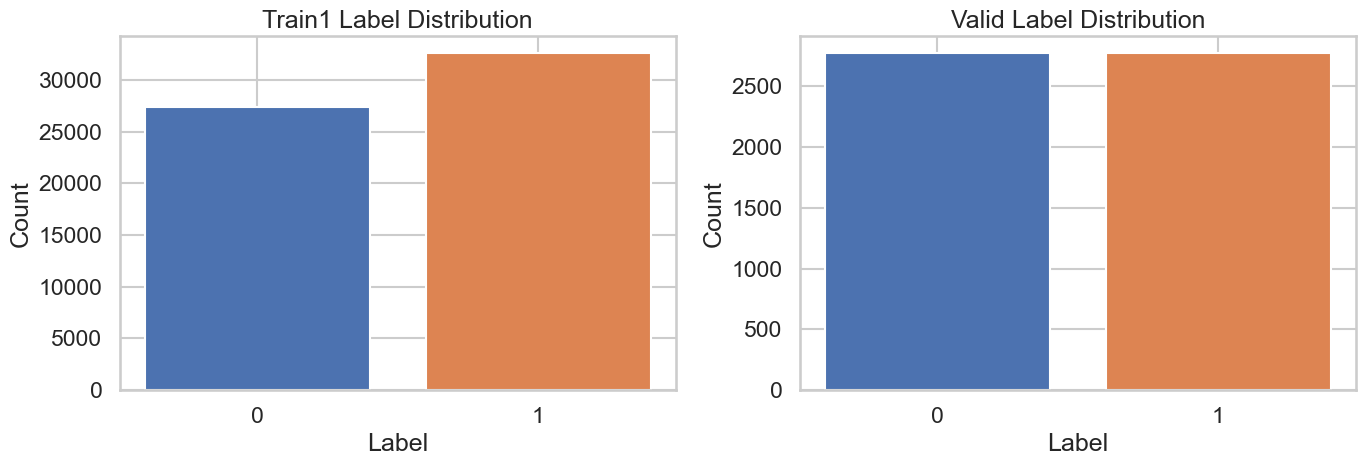

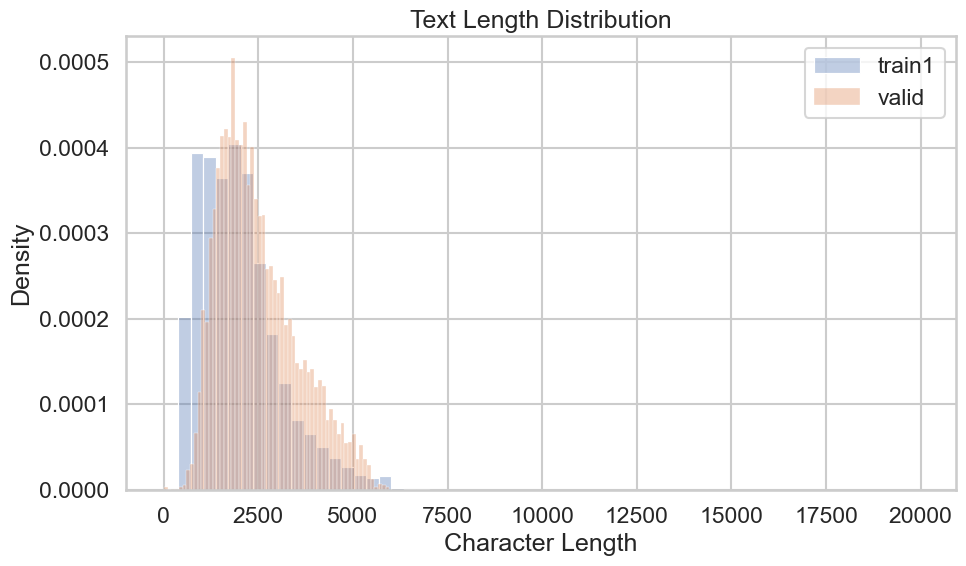

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

sns.set_theme(style='whitegrid', context='talk')
PLOT_DIR = OUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 1) 标签分布
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
train_label_counts = train1['label'].value_counts().sort_index()
valid_label_counts = valid['label'].value_counts().sort_index()
ax[0].bar(train_label_counts.index.astype(str), train_label_counts.values, color=['#4c72b0', '#dd8452'])
ax[0].set_title('Train1 Label Distribution')
ax[0].set_xlabel('Label')
ax[0].set_ylabel('Count')
ax[1].bar(valid_label_counts.index.astype(str), valid_label_counts.values, color=['#4c72b0', '#dd8452'])
ax[1].set_title('Valid Label Distribution')
ax[1].set_xlabel('Label')
ax[1].set_ylabel('Count')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_label_distribution.png', dpi=220)
plt.show()

# 2) 文本长度分布
train_len = train1['text'].str.len()
valid_len = valid['text'].str.len()
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(train_len, bins=60, stat='density', alpha=0.35, label='train1', ax=ax, color='#4c72b0')
sns.histplot(valid_len, bins=60, stat='density', alpha=0.35, label='valid', ax=ax, color='#dd8452')
ax.set_title('Text Length Distribution')
ax.set_xlabel('Character Length')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_text_length_distribution.png', dpi=220)
plt.show()


In [6]:
# Stage1
fit_corpus = valid.copy()
tok1 = train_bpe_tokenizer(fit_corpus, vocab_size=STAGE1_VOCAB_SIZE)

t1_train_tokens = [tok1.tokenize(x, add_special_tokens=False) for x in tqdm(train1['text'], desc='stage1 tokenize train')]
t1_valid_tokens = [tok1.tokenize(x, add_special_tokens=False) for x in tqdm(valid['text'], desc='stage1 tokenize valid')]
t1_test_tokens = [tok1.tokenize(x, add_special_tokens=False) for x in tqdm(test['text'], desc='stage1 tokenize test')]

t1_train_aug = augment_tokens(t1_train_tokens)
t1_valid_aug = augment_tokens(t1_valid_tokens)
t1_test_aug = augment_tokens(t1_test_tokens)

vec1, tf_train1, _ = build_features(t1_train_aug, t1_valid_aug, t1_valid_aug)
tf_valid1 = vec1.transform(t1_valid_aug)
tf_test1 = vec1.transform(t1_test_aug)

_, stage1_sgd_hist = train_sgd_history(
    tf_train1,
    train1['label'].values,
    tf_valid1,
    valid['label'].values,
    alpha=1e-4,
    epochs=12,
    random_state=42,
)

clf1 = fit_linear(tf_train1, train1['label'].values, alpha=0.023, max_iter=35000, weights=[0.2, 0.8])
vpred1 = clf1.predict_proba(tf_valid1)[:, 1]
print('Stage1 linear AUC:', roc_auc_score(valid['label'].values, vpred1))

low_idx = rankdata(vpred1) < 0.1 * len(vpred1)
high_idx = rankdata(vpred1) > 0.9 * len(vpred1)

tf_train1b = vstack([tf_train1, tf_valid1[low_idx], tf_valid1[high_idx]])
y_train1b = np.concatenate([train1['label'].values, to_label_array(int(low_idx.sum()), int(high_idx.sum()))])

clf1b = fit_linear(tf_train1b, y_train1b, alpha=0.02, max_iter=25000, weights=[0.5, 0.5])
vpred1b = clf1b.predict_proba(tf_valid1)[:, 1]
pred_stage1_test = clf1b.predict_proba(tf_test1)[:, 1]


stage1 tokenize test: 100%|██████████| 3/3 [00:00<00:00, 10791.52it/s]


Stage1 linear AUC: 0.9107531073039437
Stage1 pseudo-label AUC: 0.9251505611620902


In [7]:
# Stage2
tok2 = train_bpe_tokenizer(fit_corpus, vocab_size=STAGE2_VOCAB_SIZE)

t2_train_tokens = [tok2.tokenize(x, add_special_tokens=False) for x in tqdm(train2['text'], desc='stage2 tokenize train')]
t2_valid_tokens = [tok2.tokenize(x, add_special_tokens=False) for x in tqdm(valid['text'], desc='stage2 tokenize valid')]
t2_test_tokens = [tok2.tokenize(x, add_special_tokens=False) for x in tqdm(test['text'], desc='stage2 tokenize test')]

t2_train_aug = augment_tokens(t2_train_tokens)
t2_valid_aug = augment_tokens(t2_valid_tokens)
t2_test_aug = augment_tokens(t2_test_tokens)

vec2, tf_train2, _ = build_features(t2_train_aug, t2_valid_aug, t2_valid_aug)
tf_valid2 = vec2.transform(t2_valid_aug)
tf_test2 = vec2.transform(t2_test_aug)

_, stage2_sgd_hist = train_sgd_history(
    tf_train2,
    train2['label'].values,
    tf_valid2,
    valid['label'].values,
    alpha=1e-4,
    epochs=12,
    random_state=42,
)

clf2 = fit_linear(tf_train2, train2['label'].values, alpha=0.02, max_iter=35000, weights=[0.1, 0.9])
vpred2 = clf2.predict_proba(tf_valid2)[:, 1]
print('Stage2 linear AUC:', roc_auc_score(valid['label'].values, vpred2))

low_idx2 = rankdata(vpred2) < 0.1 * len(vpred2)
high_idx2 = rankdata(vpred2) > 0.9 * len(vpred2)

tf_train2b = vstack([tf_train2, tf_valid2[low_idx2], tf_valid2[high_idx2]])
y_train2b = np.concatenate([train2['label'].values, to_label_array(int(low_idx2.sum()), int(high_idx2.sum()))])

clf2b = fit_linear(tf_train2b, y_train2b, alpha=0.02, max_iter=25000, weights=[0.5, 0.5])
vpred2b = clf2b.predict_proba(tf_valid2)[:, 1]
pred_stage2_test = clf2b.predict_proba(tf_test2)[:, 1]


stage2 tokenize test: 100%|██████████| 3/3 [00:00<00:00, 11904.36it/s]


Stage2 linear AUC: 0.9489523980193375
Stage2 pseudo-label AUC: 0.9457236175937276


## 模型效果

Stage1/Stage2 训练后立刻绘制 ROC、混淆矩阵与分数分布。

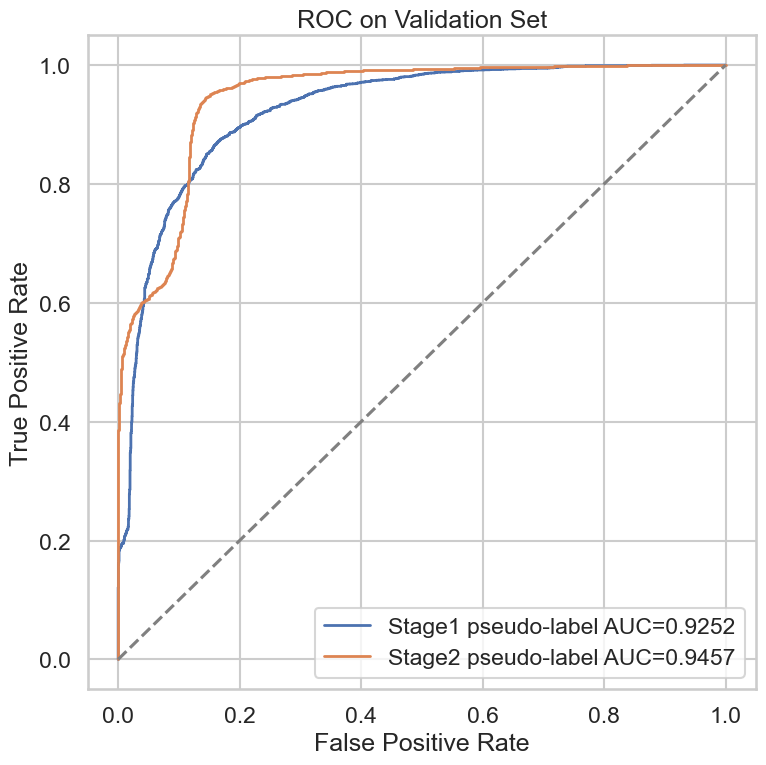

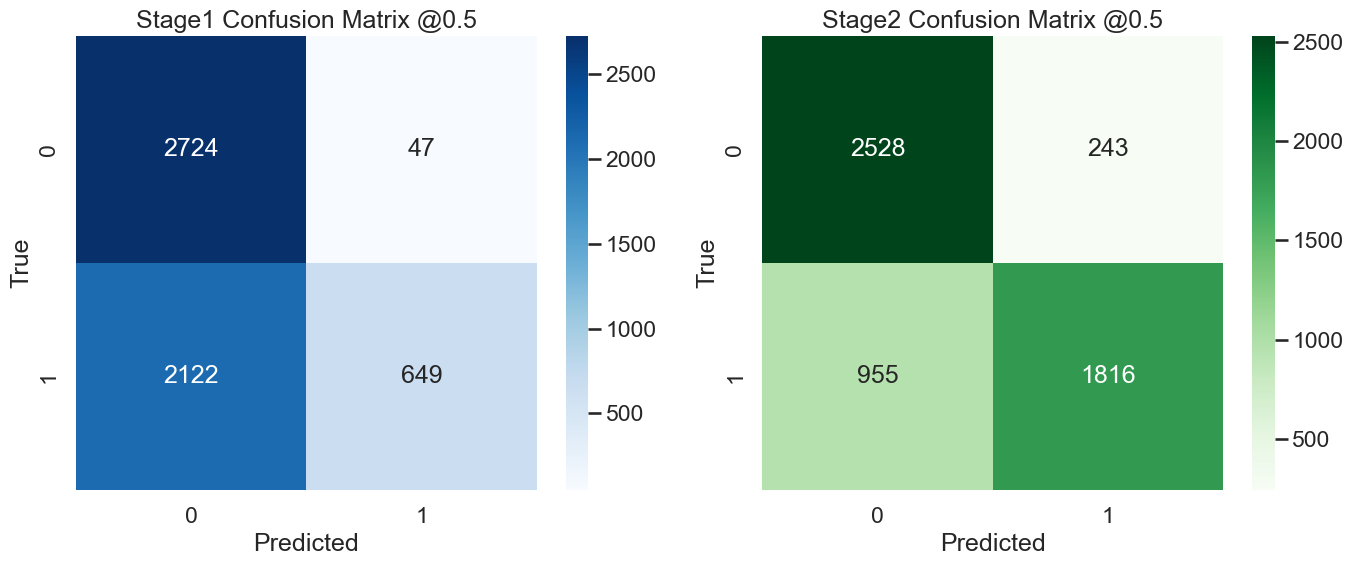

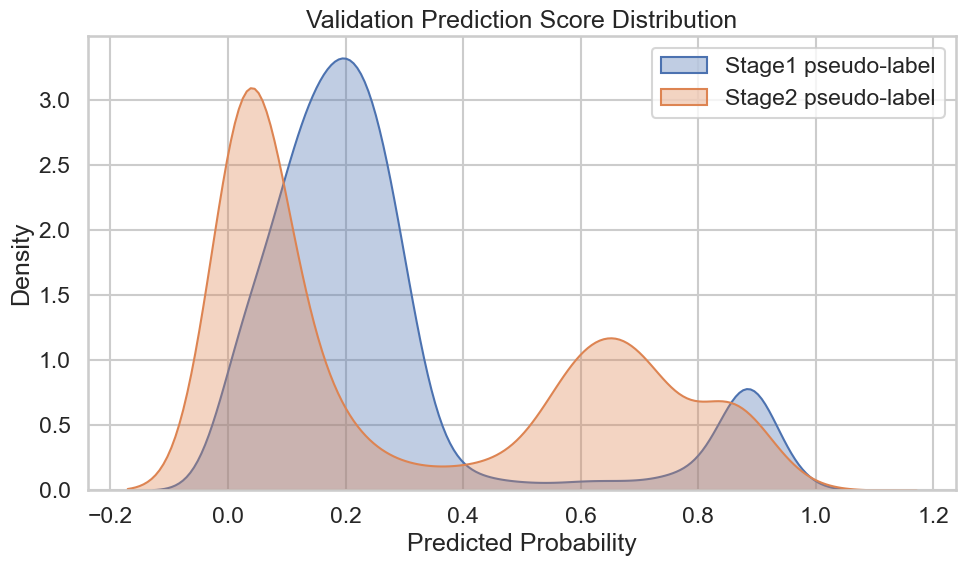

plots saved to /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/notebook_linear/plots


In [8]:
# 3) 验证集指标汇总
metrics_df = pd.DataFrame([
    evaluate_binary_metrics(valid['label'].values, vpred1b, 'Stage1 pseudo-label'),
    evaluate_binary_metrics(valid['label'].values, vpred2b, 'Stage2 pseudo-label'),
]).round(5)

print('Validation metrics:')
print(metrics_df.to_string(index=False))
metrics_df.to_csv(PLOT_DIR / 'linear_valid_metrics.csv', index=False)

metric_plot = metrics_df.set_index('model')[['auc_roc', 'accuracy', 'precision', 'recall', 'f1']]
fig, ax = plt.subplots(figsize=(12, 6))
metric_plot.T.plot(kind='bar', ax=ax)
ax.set_title('Validation Metrics Comparison')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_ylim(0.0, 1.0)
ax.legend(title='Model', loc='lower right')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_valid_metrics_bar.png', dpi=220)
plt.show()

# 4) ROC 曲线
fpr1, tpr1, _ = roc_curve(valid['label'].values, vpred1b)
fpr2, tpr2, _ = roc_curve(valid['label'].values, vpred2b)
auc1 = auc(fpr1, tpr1)
auc2 = auc(fpr2, tpr2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr1, tpr1, label=f'Stage1 pseudo-label AUC={auc1:.4f}', lw=2)
ax.plot(fpr2, tpr2, label=f'Stage2 pseudo-label AUC={auc2:.4f}', lw=2)
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.set_title('ROC on Validation Set')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_valid_roc.png', dpi=220)
plt.show()

# 5) 训练过程可视化（SGD组件）
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(stage1_sgd_hist['epoch'], stage1_sgd_hist['train_loss'], marker='o', label='Stage1 train loss')
axes[0].plot(stage1_sgd_hist['epoch'], stage1_sgd_hist['valid_loss'], marker='o', label='Stage1 valid loss')
axes[0].plot(stage2_sgd_hist['epoch'], stage2_sgd_hist['train_loss'], marker='o', label='Stage2 train loss')
axes[0].plot(stage2_sgd_hist['epoch'], stage2_sgd_hist['valid_loss'], marker='o', label='Stage2 valid loss')
axes[0].set_title('SGD Training Curve - Log Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(stage1_sgd_hist['epoch'], stage1_sgd_hist['train_auc'], marker='o', label='Stage1 train AUC')
axes[1].plot(stage1_sgd_hist['epoch'], stage1_sgd_hist['valid_auc'], marker='o', label='Stage1 valid AUC')
axes[1].plot(stage2_sgd_hist['epoch'], stage2_sgd_hist['train_auc'], marker='o', label='Stage2 train AUC')
axes[1].plot(stage2_sgd_hist['epoch'], stage2_sgd_hist['valid_auc'], marker='o', label='Stage2 valid AUC')
axes[1].set_title('SGD Training Curve - AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.0, 1.0)
axes[1].legend()

fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_training_curve_loss_auc.png', dpi=220)
plt.show()

# 6) 混淆矩阵（阈值0.5）
pred1_bin = (vpred1b >= 0.5).astype(int)
pred2_bin = (vpred2b >= 0.5).astype(int)
cm1 = confusion_matrix(valid['label'].values, pred1_bin)
cm2 = confusion_matrix(valid['label'].values, pred2_bin)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Stage1 Confusion Matrix @0.5')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Stage2 Confusion Matrix @0.5')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_valid_confusion_matrix.png', dpi=220)
plt.show()

# 7) 分数分布
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(vpred1b, fill=True, alpha=0.35, label='Stage1 pseudo-label', ax=ax)
sns.kdeplot(vpred2b, fill=True, alpha=0.35, label='Stage2 pseudo-label', ax=ax)
ax.set_title('Validation Score Distribution')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.legend()
fig.tight_layout()
fig.savefig(PLOT_DIR / 'linear_valid_score_distribution.png', dpi=220)
plt.show()


In [9]:
valid_stage1 = pd.DataFrame({'label': valid['label'].values, 'generated': vpred1b})
valid_stage2 = pd.DataFrame({'label': valid['label'].values, 'generated': vpred2b})
sub_stage1 = pd.DataFrame({'id': test['id'], 'generated': pred_stage1_test})
sub_stage2 = pd.DataFrame({'id': test['id'], 'generated': pred_stage2_test})

valid_stage1.to_csv(OUT_DIR / 'valid_pred_stage1_linear.csv', index=False)
valid_stage2.to_csv(OUT_DIR / 'valid_pred_stage2_linear.csv', index=False)
sub_stage1.to_csv(OUT_DIR / 'sub_stage1_linear_only.csv', index=False)
sub_stage2.to_csv(OUT_DIR / 'sub_stage2_linear_only.csv', index=False)
metrics_df.to_csv(OUT_DIR / 'linear_valid_metrics.csv', index=False)
stage1_sgd_hist.to_csv(OUT_DIR / 'stage1_sgd_history.csv', index=False)
stage2_sgd_hist.to_csv(OUT_DIR / 'stage2_sgd_history.csv', index=False)

print('saved to', OUT_DIR)
gc.collect()


saved to /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/notebook_linear


15883